# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset.

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [3]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Inspect the shapes of the datasets

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')


# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}')



X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


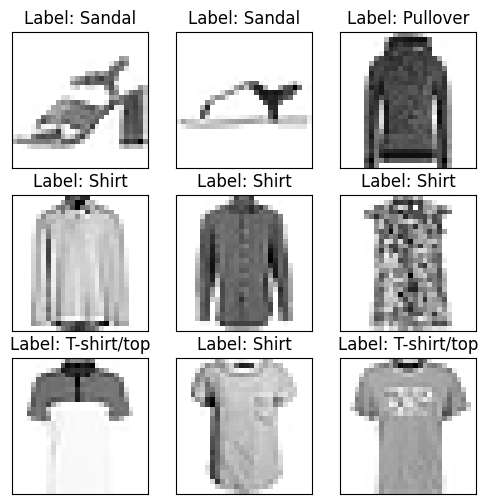

In [5]:
import matplotlib.pyplot as plt
import numpy as np
# Verify the data looks as expected

# Selecting 9 random indices
random_indices = np.random.choice(len(X_train), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {class_names[y_train[random_indices[i]].argmax()]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

The data looks as expected, given this is a sample. There are some clothing items that are repeated twice, and they still show up under correct labels, which is promising. While quality of images isn't great, it's good enough to discern between items.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [8]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()

# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28)))

# Input layer
model.add(Dense(64, activation='relu', input_shape=(64,)))

# Hidden layer
model.add(Dense(64, activation='relu'))

# Output layer
model.add(Dense(10, activation='softmax'))

model.summary()

# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model with `model.fit()`
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)
# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5980 - loss: 1.2184 - val_accuracy: 0.7627 - val_loss: 0.6437
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8072 - loss: 0.5510 - val_accuracy: 0.8313 - val_loss: 0.4906
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8321 - loss: 0.4807 - val_accuracy: 0.8364 - val_loss: 0.4607
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8461 - loss: 0.4383 - val_accuracy: 0.8473 - val_loss: 0.4300
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8508 - loss: 0.4283 - val_accuracy: 0.8488 - val_loss: 0.4264
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8456 - loss: 0.4388
Loss:     0.45
Accuracy: 83.95%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

It's about 84%, showing that the model can recognize patterns in the images without using advanced layers.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [9]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

model.add(Flatten())

model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=32,
                    validation_split=0.1,
                    verbose=2)


# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest accuracy: {accuracy * 100:.2f}%")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 - 22s - 13ms/step - accuracy: 0.8575 - loss: 0.4035 - val_accuracy: 0.8835 - val_loss: 0.3180
Epoch 2/5
1688/1688 - 21s - 13ms/step - accuracy: 0.8988 - loss: 0.2859 - val_accuracy: 0.8957 - val_loss: 0.2945
Epoch 3/5
1688/1688 - 21s - 12ms/step - accuracy: 0.9101 - loss: 0.2499 - val_accuracy: 0.8933 - val_loss: 0.3097
Epoch 4/5
1688/1688 - 39s - 23ms/step - accuracy: 0.9201 - loss: 0.2218 - val_accuracy: 0.8947 - val_loss: 0.2972
Epoch 5/5
1688/1688 - 21s - 12ms/step - accuracy: 0.9288 - loss: 0.1996 - val_accuracy: 0.9047 - val_loss: 0.2785
313/313 - 2s - 8ms/step - accuracy: 0.9005 - loss: 0.2862

Test accuracy: 90.05%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

Yes, it performed ~5% better than the baseline. This likely came from the model now being able to better distinguish across different patterns.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [14]:
# A. Test Hyperparameters

def build_model(filters):
    model = Sequential()
    model.add(Conv2D(filters=filters, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(Flatten())
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

filters_list = [32, 64, 128]
filter_results = {}

for f in filters_list:
    print(f"\nTraining model with {f} filters")
    model = build_model(f)
    model.fit(X_train, y_train,
              epochs=5,
              batch_size=32,
              validation_split=0.1,
              verbose=0)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    filter_results[f] = acc
    print(f"Test accuracy with {f} filters: {acc:.4f}")

    print("\nSummary of filter experiment:")
for f, acc in filter_results.items():
    print(f"{f} filters → Test Accuracy: {acc:.4f}")


Training model with 32 filters
Test accuracy with 32 filters: 0.8973

Summary of filter experiment:

Training model with 64 filters
Test accuracy with 64 filters: 0.9001

Summary of filter experiment:

Training model with 128 filters
Test accuracy with 128 filters: 0.9031

Summary of filter experiment:
32 filters → Test Accuracy: 0.8973
64 filters → Test Accuracy: 0.9001
128 filters → Test Accuracy: 0.9031


In [15]:
# B. Test presence or absence of regularization

from keras.layers import Dropout

def build_model_with_dropout(use_dropout=False):
    model = Sequential()
    model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

    if use_dropout:
        model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

dropout_settings = [False, True]
dropout_results = {}

for use_dropout in dropout_settings:
    label = 'With Dropout' if use_dropout else 'Without Dropout'
    print(f"\nTraining model: {label}")

    model = build_model_with_dropout(use_dropout)
    model.fit(X_train, y_train,
              epochs=5,
              batch_size=32,
              validation_split=0.1,
              verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    dropout_results[label] = acc
    print(f"Test accuracy {label}: {acc:.4f}")

print("\nSummary of regularization experiment:")
for label, acc in dropout_results.items():
    print(f"{label} → Test Accuracy: {acc:.4f}")


Training model: Without Dropout
Test accuracy Without Dropout: 0.8890

Training model: With Dropout
Test accuracy With Dropout: 0.8909

Summary of regularization experiment:
Without Dropout → Test Accuracy: 0.8890
With Dropout → Test Accuracy: 0.8909


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

Neither change (fileters or dropout) made a big impact. It seems like small changes to architecture don't always lead to major results, especially if the model is already performing well.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [16]:
optimized_model = Sequential()
optimized_model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
optimized_model.add(Dropout(0.5))
optimized_model.add(Flatten())
optimized_model.add(Dense(10, activation='softmax'))

optimized_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = optimized_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=2
)

loss, accuracy = optimized_model.evaluate(X_test, y_test, verbose=2)
print(f"\nOptimized Model Test Accuracy: {accuracy * 100:.2f}%")

Epoch 1/5
1688/1688 - 112s - 66ms/step - accuracy: 0.8583 - loss: 0.4032 - val_accuracy: 0.8563 - val_loss: 0.3726
Epoch 2/5
1688/1688 - 110s - 65ms/step - accuracy: 0.8933 - loss: 0.2954 - val_accuracy: 0.8835 - val_loss: 0.3215
Epoch 3/5
1688/1688 - 143s - 85ms/step - accuracy: 0.9058 - loss: 0.2573 - val_accuracy: 0.8988 - val_loss: 0.2926
Epoch 4/5
1688/1688 - 110s - 65ms/step - accuracy: 0.9152 - loss: 0.2312 - val_accuracy: 0.8932 - val_loss: 0.3033
Epoch 5/5
1688/1688 - 115s - 68ms/step - accuracy: 0.9235 - loss: 0.2091 - val_accuracy: 0.8913 - val_loss: 0.3134
313/313 - 3s - 9ms/step - accuracy: 0.8897 - loss: 0.3127

Optimized Model Test Accuracy: 88.97%


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

The final model's performance was slighlty better than the baseline, but worse than the CNN. The drop could be due to overfitting as a result of dropout. In the future, I would try experimenting with kernel sizes to see if results could be improved.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.